# Hover Time

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Load data
#hovers = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V5/mouse_hovers_2401.csv")
#events = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V5/mouse_events_2401_norm.csv")
#df = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V5/participants_2401.csv")

hovers = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V6/mouse_hovers.csv")
events = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V6/mouse_events_norm.csv")
df = pd.read_csv("/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V6/participants.csv")

In [9]:
# Merge Condition to Events and Hovers
events = events.merge(df[["participant_id","interest"]], on="participant_id", how="inner")
hovers = hovers.merge(df[["participant_id","interest"]], on="participant_id", how="inner")

In [10]:
# Validate required columns
required = {"participant_id", "t_enter_ms", "t_leave_ms", "duration_ms"}
missing = required - set(hovers.columns)
if missing:
    raise ValueError(f"Missing required columns: {', '.join(sorted(missing))}")

# Ensure numeric types
for col in ["t_enter_ms", "t_leave_ms"]:
    hovers[col] = pd.to_numeric(hovers[col], errors="coerce")


#  Data Cleaning: keep valid, positive hover times and non-empty participant_id
hovers = hovers.loc[
    hovers["participant_id"].notna()
    & np.isfinite(hovers["duration_ms"])
    & (hovers["duration_ms"] > 0)
].copy()


# Aggregate per participant
metrics = (
    hovers.groupby("participant_id")["duration_ms"]
      .agg(total_hovertime_ms="sum",
           n_hovers="count",
           mean_hovertime_ms="mean",
           median_hovertime_ms="median",
           sd_hovertime_ms="std")      
      .reset_index()
)

# Replace NaN std with 0 for users with a single hover
metrics["sd_hovertime_ms"] = metrics["sd_hovertime_ms"].fillna(0.0)

# Calculate hovertime in seconds
metrics["total_hovertime_s"]  = metrics["total_hovertime_ms"]  / 1000.0
metrics["mean_hovertime_s"]   = metrics["mean_hovertime_ms"]   / 1000.0
metrics["median_hovertime_s"] = metrics["median_hovertime_ms"] / 1000.0
metrics["sd_hovertime_s"]    = metrics["sd_hovertime_ms"]    / 1000.0


# Print
display(metrics.head(10))


,participant_id,total_hovertime_ms,n_hovers,mean_hovertime_ms,median_hovertime_ms,sd_hovertime_ms,total_hovertime_s,mean_hovertime_s,median_hovertime_s,sd_hovertime_s
0,01caf55c-3693-4aa3-bac2-862230173a5e,170272,57,2987.228070,1556.0,3643.946668,170.272,2.987228,1.5560,3.643947
1,01f97700-9c92-4464-9bf8-21132acaa881,63215,28,2257.678571,938.0,3138.035869,63.215,2.257679,0.9380,3.138036
2,05bcca80-e838-4ef3-8ba8-39e870310e8f,35579,12,2964.916667,1225.0,3749.400787,35.579,2.964917,1.2250,3.749401
3,09836b97-00f6-47f3-b9aa-c34ad5867121,45903,18,2550.166667,995.0,5253.010411,45.903,2.550167,0.9950,5.253010
4,0c8e7770-1c3e-40d4-af3e-561d63ec9aa3,29332,17,1725.411765,1878.0,1376.977535,29.332,1.725412,1.8780,1.376978
5,10bcc14f-7fd9-4646-80bc-7eff4d2e1097,6927,15,461.800000,217.0,522.202369,6.927,0.461800,0.2170,0.522202
6,10e43c6b-430c-47be-8c7e-acfe0fe439b5,27442,10,2744.200000,483.5,5095.110026,27.442,2.744200,0.4835,5.095110
7,125fe34e-d1f0-498a-8fd0-5d0cf21e030d,25496,17,1499.764706,809.0,1914.712398,25.496,1.499765,0.8090,1.914712
8,15b9dd42-a1f4-43d2-a040-9bfa65d63082,65023,14,4644.500000,2881.5,4112.814285,65.023,4.644500,2.8815,4.112814
9,1826a545-f6f3-47b9-a091-81477ba89250,48314,18,2684.111111,894.0,5498.613589,48.314,2.684111,0.8940,5.498614


In [14]:
# Save hover metrics to CSV
hover_metrics_path = "/Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V6/hover_metrics.csv" 
metrics.to_csv(hover_metrics_path, index=False)

print(f"Saved hover metrics to: {hover_metrics_path}")


Saved hover metrics to: /Users/marlenerueschoff/Documents/Uni/UzK Master/Masterarbeit/Experiment/masterthesis_experiment-1/Data/V6/hover_metrics.csv


# Visualization

/var/folders/v_/5q_t13ds7pz7yhp0h3fhnrr40000gn/T/ipykernel_3772/4122006710.py:118: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_: df_.sample(n=min(N_EXAMPLES_PER_INTEREST, len(df_)), random_state=RANDOM_STATE))[


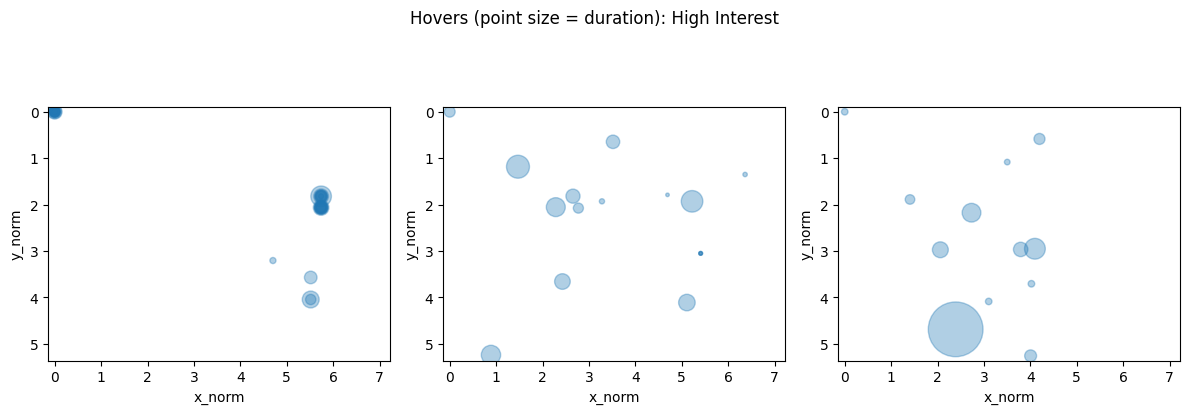

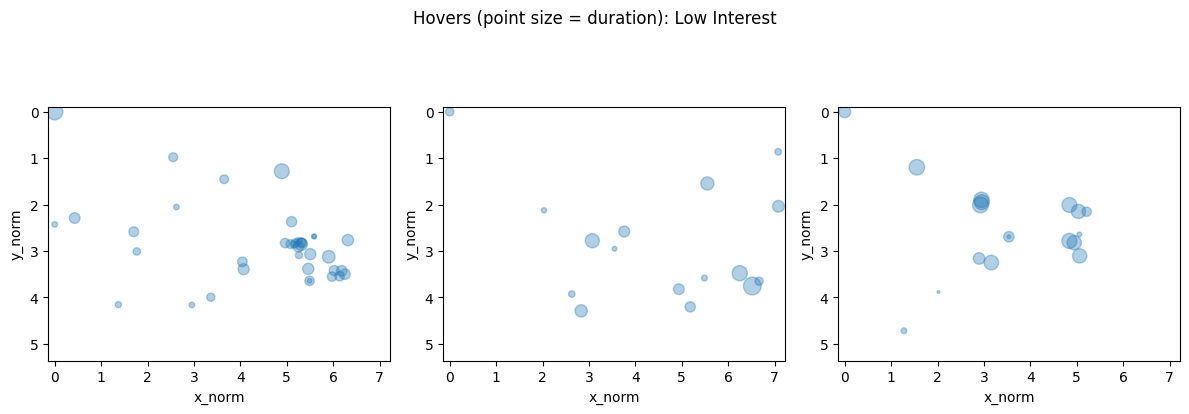

In [26]:
##################### Basic Cleaning #####################

# Strip whitespace from column names
hovers.columns = hovers.columns.str.strip()
events.columns = events.columns.str.strip()

# Ensure timestamps are numeric
hovers["t_enter_ms"] = pd.to_numeric(hovers["t_enter_ms"], errors="coerce")
events["t_ms"]       = pd.to_numeric(events["t_ms"], errors="coerce")

# Ensure x_norm / y_norm exist in events
if "x_norm" not in events.columns or "y_norm" not in events.columns:
    raise KeyError("Columns 'x_norm'/'y_norm' not found in events. Please create them first.")

# Drop rows with missing join keys / required fields
hovers = hovers.dropna(subset=["participant_id", "session_id", "task", "t_enter_ms"]).copy()
events = events.dropna(subset=["participant_id", "session_id", "task", "t_ms", "x_norm", "y_norm"]).copy()

# Ensure interest exists in events
if "interest" not in events.columns:
    raise KeyError("Column 'interest' not found in events. Please merge it into events first.")

# --- CRITICAL FIX: merge_asof requires identical dtypes on merge keys ---
# Use int64 milliseconds for both (round in case there are decimals)
hovers["t_enter_ms"] = hovers["t_enter_ms"].round().astype("int64")
events["t_ms"]       = events["t_ms"].round().astype("int64")


##################### Map Hovers to Cursor Positions #####################

# Keep only required columns from events
events_take = events[["participant_id", "session_id", "task", "t_ms", "x_norm", "y_norm", "interest"]].copy()

# Build per-group event streams (sorted)
ev_groups = {
    key: g.sort_values("t_ms", kind="mergesort")[["t_ms", "x_norm", "y_norm", "interest"]].reset_index(drop=True)
    for key, g in events_take.groupby(["participant_id", "session_id", "task"], sort=False)
}

mapped_parts = []

for key, h in hovers.groupby(["participant_id", "session_id", "task"], sort=False):
    h = h.sort_values("t_enter_ms", kind="mergesort").reset_index(drop=True)
    e = ev_groups.get(key)

    # If no events exist for this group, keep hover rows with NaNs for mapped position
    if e is None or e.empty:
        h = h.copy()
        h["x_norm"] = np.nan
        h["y_norm"] = np.nan
        h["interest"] = np.nan
        mapped_parts.append(h)
        continue

    # Map each hover to the last cursor position at/before hover start
    mapped = pd.merge_asof(
        h,
        e,
        left_on="t_enter_ms",
        right_on="t_ms",
        direction="backward",
        tolerance=200,   # ms
        suffixes=("", "_evt"),
    )
    mapped_parts.append(mapped)

hov_pos = pd.concat(mapped_parts, ignore_index=True)


##################### Ensure Clean Interest Column #####################

if "interest" not in hov_pos.columns:
    candidates = [c for c in hov_pos.columns if c.lower().startswith("interest")]

    # If no candidate exists, fall back to merging interest by participant_id
    if len(candidates) == 0:
        interest_map = (
            events[["participant_id", "interest"]]
            .dropna()
            .drop_duplicates("participant_id")
        )
        hov_pos = hov_pos.merge(interest_map, on="participant_id", how="left")
    else:
        # Prefer the event-sourced column if present
        prefer = "interest_evt" if "interest_evt" in candidates else candidates[0]
        hov_pos = hov_pos.rename(columns={prefer: "interest"})


##################### Point Sizes from Hover Duration #####################

# Ensure duration exists
if "duration_ms" not in hov_pos.columns:
    raise KeyError("Column 'duration_ms' not found in hovers/merged data.")

# Drop rows where mapping failed or required fields are missing
hov_pos = hov_pos.dropna(subset=["x_norm", "y_norm", "interest", "duration_ms"]).copy()

# Convert hover duration to point size
SIZE_SCALE = 2.0
dur = hov_pos["duration_ms"].clip(lower=1)
hov_pos["size"] = np.sqrt(dur) * SIZE_SCALE


##################### Sample Participants and Plot #####################

# Plot settings
N_EXAMPLES_PER_INTEREST = 3
RANDOM_STATE            = 4
ALPHA_POINTS            = 0.35

np.random.seed(RANDOM_STATE)

# Sample up to N_EXAMPLES_PER_INTEREST participants per interest group
unique_p = hov_pos[["participant_id", "interest"]].drop_duplicates()

sampled_ids = (
    unique_p.groupby("interest", group_keys=False)
            .apply(lambda df_: df_.sample(n=min(N_EXAMPLES_PER_INTEREST, len(df_)), random_state=RANDOM_STATE))[
                "participant_id"
            ]
            .tolist()
)

hov_plot = hov_pos[hov_pos["participant_id"].isin(sampled_ids)].copy()

# --------- OPTION A: global axis limits so every coordinate system is identical ---------
xmin, xmax = hov_plot["x_norm"].min(), hov_plot["x_norm"].max()
ymin, ymax = hov_plot["y_norm"].min(), hov_plot["y_norm"].max()

# optional padding
pad = 0.02
xr = xmax - xmin
yr = ymax - ymin
if xr == 0:  # safety for degenerate cases
    xr = 1e-6
if yr == 0:
    yr = 1e-6

xmin, xmax = xmin - pad * xr, xmax + pad * xr
ymin, ymax = ymin - pad * yr, ymax + pad * yr
# ----------------------------------------------------------------------

# One figure per interest, with up to 3 participants in a lane
for interest, g in hov_plot.groupby("interest"):
    pids = g["participant_id"].drop_duplicates().tolist()
    n = len(pids)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, pid in zip(axes, pids):
        d = g[g["participant_id"] == pid]

        # Scatter hover locations sized by hover duration
        ax.scatter(d["x_norm"], d["y_norm"], s=d["size"], alpha=ALPHA_POINTS)

        # SAME LIMITS ON EVERY SUBPLOT (and y inverted)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymax, ymin)  # inverted axis in one go (no invert_yaxis needed)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x_norm")
        ax.set_ylabel("y_norm")

    fig.suptitle(f"Hovers (point size = duration): {interest} Interest", y=1.02)
    plt.tight_layout()
    plt.show()
